In [1]:
# dropout, bn, 自定义图片数据集
# 迁移学习

In [64]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torchvision

In [3]:
base_dir = './dataset/image'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

In [4]:
filenames = os.listdir('./dataset/image')

In [5]:
len(filenames)

1127

In [6]:
species = ['cloudy', 'rain', 'shine', 'sunrise']

In [16]:
# 创建train和test目录
if not os.path.exists(train_dir):
    os.mkdir(train_dir)
if not os.path.exists(test_dir):
    os.mkdir(test_dir)

In [17]:
# 分别在train和test目录下创建4种类别的目录
for train_or_test in ['train', 'test']:
    for spec in species:
        path = os.path.join(base_dir, train_or_test , spec)
        os.mkdir(path)

In [19]:
# python中的自带的拷贝工具
import shutil

In [20]:
# 要判断一个图片属于哪个类别
# 'cloudy' in img

In [25]:
# 要把dataset中的图片全部拷贝到train, test目录下的4个子目录中
for i, img in enumerate(filenames):
    img_path = os.path.join(base_dir, img)

    if os.path.isdir(img_path):
        continue
    for spec in species:
        if spec in img:
            # 确定是划分为 test 还是 train
            # sub_folder = 'test' if i % 5 == 0 else 'train'
            
            # # 构建目标目录路径 (例如: ./dataset/image/train/cat)
            # target_dir = os.path.join(base_dir, sub_folder, spec)
            
            # # 【关键修改 2】如果目标文件夹不存在，则递归创建
            # if not os.path.exists(target_dir):
            #     os.makedirs(target_dir)
            
            # # 构建完整的目标文件路径
            # target_path = os.path.join(target_dir, img)
            
            # # 执行复制
            # shutil.copy(img_path, target_path)
            # break # 匹配到一个物种后即可跳出内层循环
            if i % 5 == 0:
                path = os.path.join(base_dir, 'test', spec, img)
            else:
                path = os.path.join(base_dir, 'train', spec, img)
            shutil.copy(img_path, path)

In [26]:
# 打印每个类别训练数据和测试数据分别有多少图片
for train_or_test in ['train', 'test']:
    for spec in species:
        print(train_or_test, spec, len(os.listdir(os.path.join(base_dir, train_or_test, spec))))


train cloudy 240
train rain 172
train shine 202
train sunrise 286
test cloudy 60
test rain 43
test shine 51
test sunrise 71


In [27]:
from torchvision import transforms

In [29]:
transform = transforms.Compose([
    # 统一缩放到 96 * 96
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    # 正则化
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [91]:
train_ds = torchvision.datasets.ImageFolder(train_dir, transform=transform)

In [92]:
test_ds = torchvision.datasets.ImageFolder(test_dir, transform=transform)

In [33]:
train_ds.classes

['cloudy', 'rain', 'shine', 'sunrise']

In [34]:
train_ds.class_to_idx

{'cloudy': 0, 'rain': 1, 'shine': 2, 'sunrise': 3}

In [35]:
len(train_ds)

900

In [36]:
len(test_ds)

225

In [38]:
batch_size = 32

In [93]:
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=batch_size)

In [41]:
imgs, labels = next(iter(train_dl))

In [42]:
imgs.shape

torch.Size([32, 3, 96, 96])

In [43]:
labels

tensor([1, 2, 3, 2, 0, 0, 1, 0, 2, 1, 2, 0, 3, 2, 3, 1, 2, 0, 2, 2, 3, 0, 0, 1,
        2, 1, 2, 0, 2, 3, 3, 3])

In [46]:
# 显示一张图片
img = imgs[0]
img.shape

torch.Size([3, 96, 96])

In [47]:
# squeeze, 只能把维度是1的地方压缩掉   (28, 28, 1) -> (28, 28)

In [53]:
# torch.transpose()
img
img.min()
img.max()
img = img + 1
img = img/2
img

tensor([[[0.5392, 0.5627, 0.5902,  ..., 0.5196, 0.5510, 0.5627],
         [0.5314, 0.5745, 0.5510,  ..., 0.5431, 0.5196, 0.5275],
         [0.5314, 0.6176, 0.5627,  ..., 0.5431, 0.5353, 0.5471],
         ...,
         [0.8294, 0.8294, 0.8294,  ..., 0.8647, 0.7863, 0.8412],
         [0.8059, 0.8137, 0.8098,  ..., 0.8412, 0.7863, 0.8137],
         [0.8608, 0.8725, 0.8647,  ..., 0.8882, 0.8294, 0.8412]],

        [[0.5392, 0.5627, 0.5902,  ..., 0.5196, 0.5510, 0.5627],
         [0.5314, 0.5745, 0.5510,  ..., 0.5431, 0.5196, 0.5275],
         [0.5314, 0.6176, 0.5627,  ..., 0.5431, 0.5353, 0.5471],
         ...,
         [0.8333, 0.8333, 0.8333,  ..., 0.9000, 0.8216, 0.8686],
         [0.8098, 0.8176, 0.8137,  ..., 0.8765, 0.8216, 0.8451],
         [0.8647, 0.8765, 0.8686,  ..., 0.9235, 0.8647, 0.8765]],

        [[0.5353, 0.5549, 0.5824,  ..., 0.5157, 0.5431, 0.5627],
         [0.5275, 0.5706, 0.5471,  ..., 0.5392, 0.5157, 0.5275],
         [0.5235, 0.6098, 0.5549,  ..., 0.5353, 0.5275, 0.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..1.4529412].


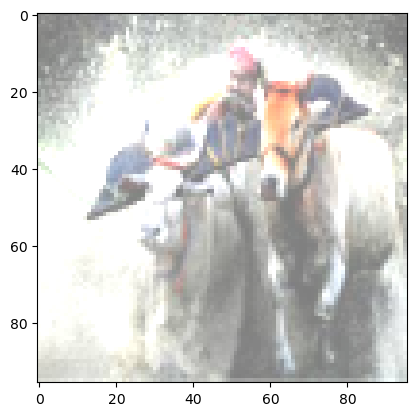

In [54]:
# reshape不可以, 会打乱数据
plt.imshow(img.permute(1, 2, 0))

In [84]:
# 定义模型
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3) # 16 * 94 * 94
        self.pool = nn.MaxPool2d(2, 2) # 16 * 47 *47
        self.conv2 = nn.Conv2d(16, 32, 3) # 32 * 45 * 45 -> pooling -> 32 * 22 * 22
        self.conv3 = nn.Conv2d(32, 64, 3) # 64 * 20 * 20 -> pooling -> 64 * 10 * 10
        self.dropout = nn.Dropout()

        # batch, channel, height, width, 64
        self.fc1 = nn.Linear(64 * 10 * 10, 1024)
        self.fc2 = nn.Linear(1024, 256)
        self.fc3 = nn.Linear(256, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        # x.view(-1, 64 * 10 * 10)
        x = nn.Flatten()(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


In [78]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [79]:
model = Net()
# 把model拷到GPU上
if torch.cuda.is_available():
    model.to(device)

In [80]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [81]:
def fit(epoch, model, train_loader, test_loader):
    correct = 0
    total = 0
    running_loss = 0

    for x, y in train_loader:
        # 把数据放到GPU上去.
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            y_pred = torch.argmax(y_pred, dim=1)
            correct += (y_pred == y).sum().item()
            total += y.size(0)
            running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total

    # 测试过程
    test_correct = 0
    test_total = 0
    test_running_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            # 把数据放到GPU上去.
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            loss = loss_fn(y_pred, y)
 
            y_pred = torch.argmax(y_pred, dim=1)
            test_correct += (y_pred == y).sum().item()
            test_total += y.size(0)
            test_running_loss += loss.item()

    test_epoch_loss = test_running_loss / len(test_loader.dataset)
    test_epoch_acc = test_correct / test_total

    print('epoch: ', epoch,
         'loss: ', round(epoch_loss, 3),
         'accuracy: ', round(epoch_acc, 3),
         'test_loss: ', round(test_epoch_loss, 3),
         'test_accuracy: ', round(test_epoch_acc, 3)
         )
    return epoch_loss, epoch_acc, test_epoch_loss, test_epoch_acc

In [82]:
epochs = 20
train_loss = []
train_acc = []
test_loss = []
test_acc = []
for epoch in range(epochs):
    epoch_loss, epoch_acc, test_epoch_loss, test_epoch_acc =  fit(epoch, model, train_dl, test_dl)
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)

    test_loss.append(test_epoch_loss)
    test_acc.append(test_epoch_acc)

epoch:  0 loss:  0.032 accuracy:  0.538 test_loss:  0.026 test_accuracy:  0.653
epoch:  1 loss:  0.02 accuracy:  0.708 test_loss:  0.022 test_accuracy:  0.742
epoch:  2 loss:  0.017 accuracy:  0.77 test_loss:  0.022 test_accuracy:  0.8
epoch:  3 loss:  0.014 accuracy:  0.84 test_loss:  0.018 test_accuracy:  0.827
epoch:  4 loss:  0.012 accuracy:  0.857 test_loss:  0.015 test_accuracy:  0.858
epoch:  5 loss:  0.011 accuracy:  0.876 test_loss:  0.014 test_accuracy:  0.889
epoch:  6 loss:  0.01 accuracy:  0.889 test_loss:  0.017 test_accuracy:  0.88
epoch:  7 loss:  0.011 accuracy:  0.901 test_loss:  0.024 test_accuracy:  0.831
epoch:  8 loss:  0.011 accuracy:  0.903 test_loss:  0.018 test_accuracy:  0.858
epoch:  9 loss:  0.009 accuracy:  0.908 test_loss:  0.02 test_accuracy:  0.84
epoch:  10 loss:  0.008 accuracy:  0.91 test_loss:  0.015 test_accuracy:  0.889
epoch:  11 loss:  0.007 accuracy:  0.927 test_loss:  0.016 test_accuracy:  0.88
epoch:  12 loss:  0.006 accuracy:  0.938 test_los

In [88]:
# 添加BN层
# 定义模型
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3) # 16 * 94 * 94
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2) # 16 * 47 *47
        self.conv2 = nn.Conv2d(16, 32, 3) # 32 * 45 * 45 -> pooling -> 32 * 22 * 22
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, 3) # 64 * 20 * 20 -> pooling -> 64 * 10 * 10
        self.bn3 = nn.BatchNorm2d(64)
        self.dropout = nn.Dropout()

        # batch, channel, height, width, 64
        self.fc1 = nn.Linear(64 * 10 * 10, 1024)
        self.bn_fc1 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, 256)
        self.bn_fc2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.bn1(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.bn2(x)
        x = self.pool(F.relu(self.conv3(x)))
        x = self.bn3(x)
        # x.view(-1, 64 * 10 * 10)
        x = nn.Flatten()(x)
        x = F.relu(self.fc1(x))
        x = self.bn_fc1(x)
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.bn_fc2(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [89]:
model = Net()
# 把model拷到GPU上
if torch.cuda.is_available():
    model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [94]:
epochs = 20
train_loss = []
train_acc = []
test_loss = []
test_acc = []
for epoch in range(epochs):
    epoch_loss, epoch_acc, test_epoch_loss, test_epoch_acc =  fit(epoch, model, train_dl, test_dl)
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)

    test_loss.append(test_epoch_loss)
    test_acc.append(test_epoch_acc)

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 1024])